In [10]:
pip install tensorflow==2.18.0


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install keras==3.7.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install optree

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from keras.layers import Input, Lambda, Dense, Flatten
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential  # For Sequential models
from tensorflow.keras.models import Model        # For functional API models (if needed)
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [14]:
IMAGE_SIZE = [224,224]

In [15]:
train_directory=r'C:\Users\AKHIL\Desktop\Final Dataset\Train\Nail'
test_directory=r'C:\Users\AKHIL\Desktop\Final Dataset\Test\Nail'
val_directory=r'C:\Users\AKHIL\Desktop\Final Dataset\Valid\Nail'

In [16]:


from keras.applications.vgg16 import VGG16
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# don't train existing weights
for layer in vgg.layers:
  layer.trainable = False

In [17]:
  # useful for getting number of classes
from glob import glob
folders = glob(r'C:\Users\AKHIL\Desktop\Final Dataset\Test\Nail')
len(folders)

1

In [18]:
# our layers - you can add more if you want
from keras.layers import Input, Lambda, Dense, Flatten
x = Flatten()(vgg.output)
# x = Dense(1000, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

In [19]:
# create a model object
from tensorflow.keras.models import Model 
model = Model(inputs=vgg.input, outputs=prediction)

# view the structure of the model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_directory = r"C:\Users\AKHIL\Desktop\Final Dataset\Train\Nail"  # Replace with the actual path
test_directory = r"C:\Users\AKHIL\Desktop\Final Dataset\Test\Nail"  # Replace with the actual path

train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(train_directory,
                                                 target_size=(150, 150),
                                                 batch_size=32,
                                                 class_mode='categorical')

test_set = test_datagen.flow_from_directory(test_directory,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')


Found 900 images belonging to 3 classes.
Found 210 images belonging to 3 classes.


In [22]:
print(len(training_set))
print(len(test_set))

29
7


In [23]:
import scipy
from scipy import linalg
print(linalg.__doc__)



Linear algebra (:mod:`scipy.linalg`)

.. currentmodule:: scipy.linalg

.. toctree::
   :hidden:

   linalg.blas
   linalg.cython_blas
   linalg.cython_lapack
   linalg.interpolative
   linalg.lapack

Linear algebra functions.

.. eventually, we should replace the numpy.linalg HTML link with just `numpy.linalg`

.. seealso::

   `numpy.linalg <https://www.numpy.org/devdocs/reference/routines.linalg.html>`__
   for more linear algebra functions. Note that
   although `scipy.linalg` imports most of them, identically named
   functions from `scipy.linalg` may offer more or slightly differing
   functionality.


Basics

.. autosummary::
   :toctree: generated/

   inv - Find the inverse of a square matrix
   solve - Solve a linear system of equations
   solve_banded - Solve a banded linear system
   solveh_banded - Solve a Hermitian or symmetric banded system
   solve_circulant - Solve a circulant system
   solve_triangular - Solve a triangular matrix
   solve_toeplitz - Solve a toeplitz m

In [15]:
from scipy import ndimage
from scipy import linalg
print(ndimage.__doc__)



Multidimensional image processing (:mod:`scipy.ndimage`)

.. currentmodule:: scipy.ndimage

This package contains various functions for multidimensional image
processing.


Filters

.. autosummary::
   :toctree: generated/

   convolve - Multidimensional convolution
   convolve1d - 1-D convolution along the given axis
   correlate - Multidimensional correlation
   correlate1d - 1-D correlation along the given axis
   gaussian_filter
   gaussian_filter1d
   gaussian_gradient_magnitude
   gaussian_laplace
   generic_filter - Multidimensional filter using a given function
   generic_filter1d - 1-D generic filter along the given axis
   generic_gradient_magnitude
   generic_laplace
   laplace - N-D Laplace filter based on approximate second derivatives
   maximum_filter
   maximum_filter1d
   median_filter - Calculates a multidimensional median filter
   minimum_filter
   minimum_filter1d
   percentile_filter - Calculates a multidimensional percentile filter
   prewitt
   rank_filter - Ca

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define Image Data Generator
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load dataset (Make sure the paths are correct)
train_directory =r"C:\Users\AKHIL\Desktop\Final Dataset\Train\Nail"
test_directory = r"C:\Users\AKHIL\Desktop\Final Dataset\Test\Nail"

training_set = train_datagen.flow_from_directory(train_directory,
                                                 target_size=(150,150),  # Match with model input
                                                 batch_size=32,
                                                 class_mode='categorical')

test_set = test_datagen.flow_from_directory(test_directory,
                                            target_size=(150,150),  # Match with model input
                                            batch_size=32,
                                            class_mode='categorical')

Found 900 images belonging to 3 classes.
Found 210 images belonging to 3 classes.


In [4]:
print(training_set.class_indices)
print(test_set.class_indices)

{'aloperia areata': 0, 'beau_s lines': 1, 'bluish nail': 2}
{'aloperia areata': 0, 'beau_s lines': 1, 'bluish nail': 2}


In [14]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define Image Data Generator
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load dataset (Make sure the paths are correct)
train_directory =r"C:\Users\AKHIL\Desktop\Final Dataset\Train\Nail"
test_directory = r"C:\Users\AKHIL\Desktop\Final Dataset\Test\Nail"

training_set = train_datagen.flow_from_directory(train_directory,
                                                 target_size=(224,224),  # Match with model input
                                                 batch_size=32,
                                                 class_mode='categorical')

test_set = test_datagen.flow_from_directory(test_directory,
                                            target_size=(224,224),  # Match with model input
                                            batch_size=32,
                                            class_mode='categorical')

# ✅ Define the Model (before calling fit)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),  # Match input size
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ Train the Model (Now this will work)
# r = model.fit(
#     training_set,
#     validation_data=test_set,
#     epochs=20,
#     steps_per_epoch=len(training_set),
#     validation_steps=len(test_set)
# )
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    'Nail_epoch_{epoch:02d}.keras',  # Save the model with the epoch number in the filename
    save_best_only=False,  # Save all models after each epoch (not just the best)
    save_weights_only=False,  # Save the entire model (architecture + weights)
    verbose=1  # Print messages when saving the model
)

# Train the model and save after each epoch
r = model.fit(
    training_set,  # Your training data generator
    validation_data=test_set,  # Your validation/test data generator
    epochs=50, # Number of batches per epoch in validation/testing
    callbacks=[checkpoint_callback]  # Add the checkpoint callback to save the model
)


Found 900 images belonging to 3 classes.
Found 210 images belonging to 3 classes.
Epoch 1/50


c:\Users\AKHIL\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\AKHIL\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.3441 - loss: 4.0924
Epoch 1: saving model to Nail_epoch_01.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 743ms/step - accuracy: 0.3453 - loss: 4.0337 - val_accuracy: 0.4048 - val_loss: 1.0241
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.5988 - loss: 0.9016
Epoch 2: saving model to Nail_epoch_02.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 688ms/step - accuracy: 0.5997 - loss: 0.9004 - val_accuracy: 0.6476 - val_loss: 0.7963
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.7208 - loss: 0.6553
Epoch 3: saving model to Nail_epoch_03.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 655ms/step - accuracy: 0.7207 - loss: 0.6557 - val_accuracy: 0.6905 - val_loss: 0.7411
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.7295 - loss: 0.6732
Epoch 4: saving model to Nail_epoch_04.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 565ms/step - accuracy: 0.7296 - loss: 0.6728 - val_accuracy: 0.6619 - val_loss: 0.7418
Epoch 5/50
29/2

In [17]:
from tensorflow.keras.models import load_model

# Load the saved model (replace 'model_epoch_14.h5' with your saved model's file name)
model = load_model('Nail_epoch_45.keras')

# Evaluate the model on your test data
# Assuming you have a test data generator (test_generator) for your test set
test_loss, test_accuracy = model.evaluate(test_set, steps=len(test_set))

# Print the test accuracy
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9315 - loss: 0.5131
Test Accuracy: 93.81%


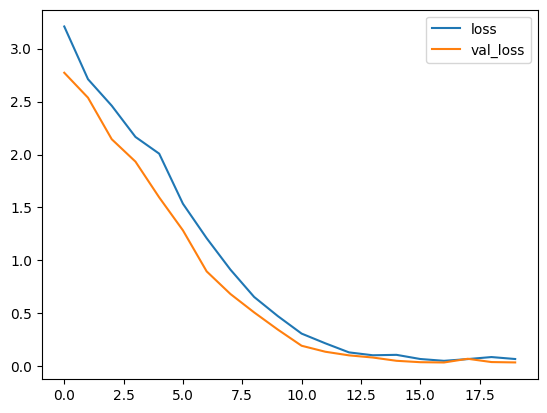

In [17]:
# loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

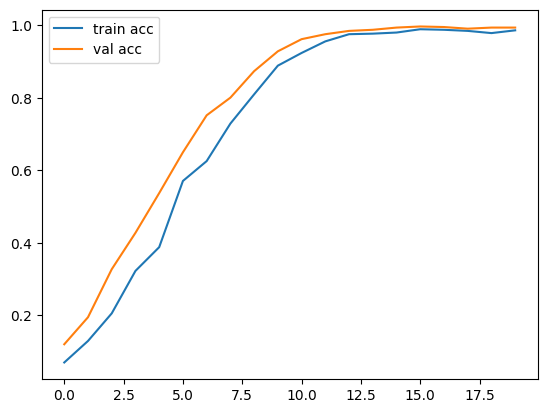

In [18]:
# accuracies
import matplotlib.pyplot as plt
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [19]:
model.save('nail_disease_model.h5')

In [120]:
lab = training_set.class_indices
lab={k:v for v,k in lab.items()}

In [121]:
def output(location):
    img=load_img(location,target_size=(150,150,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model1.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = lab[y]
    return res

In [122]:
import tensorflow as tf
import keras as k
print(tf.__version__)
print(k.__version__)

2.18.0
3.7.0


In [123]:
pip install pandas

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# Paths to the dataset (update according to your environment)
dataset_path =r"C:\Users\AKHIL\Desktop\Final Dataset\Train\Nail"  # Provide the path to the dataset

# Preprocessing using ImageDataGenerator for augmentation
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Loading the dataset into train and validation generators
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Create a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(train_gen.class_indices), activation='softmax')  # Number of classes
])

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
# model.fit(train_gen, epochs=10, validation_data=val_gen)
checkpoint_callback = ModelCheckpoint(
    'Nail_epoch_{epoch:02d}.keras',  # Save the model with the epoch number in the filename
    save_best_only=False,  # Save all models after each epoch (not just the best)
    save_weights_only=False,  # Save the entire model (architecture + weights)
    verbose=1  # Print messages when saving the model
)

# Train the model and save after each epoch
r = model.fit(
    training_set,  # Your training data generator
    validation_data=test_set,  # Your validation/test data generator
    epochs=50,
    steps_per_epoch=len(training_set),  # Number of batches per epoch in training
    validation_steps=len(test_set),  # Number of batches per epoch in validation/testing
    callbacks=[checkpoint_callback]  # Add the checkpoint callback to save the model
)


# Evaluate the model on validation data
y_true = val_gen.classes  # True labels
y_pred = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)  # Predicted class labels

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Display the confusion matrix using matplotlib
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(train_gen.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.show()


Found 720 images belonging to 3 classes.
Found 180 images belonging to 3 classes.


c:\Users\AKHIL\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_7" is incompatible with the layer: expected axis -1 of input shape to have value 57600, but received input with shape (None, 82944)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 150, 150, 3), dtype=float32)
  • training=True
  • mask=None